In [1]:
import matplotlib.pyplot as plt
import numpy
import math
import pandas
import i24_motion_macro
import i24_motion_data
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display, clear_output


In [2]:
i24data = i24_motion_data.I24MotionData(2, 1669812350, 1669812350+3600, 0, 1600)
i24macro = i24_motion_macro.I24MotionMacro(i24data, 2, "road_2")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [3]:
i24macro_data = i24macro.loadProcessedMacroData()

(36000, 32)


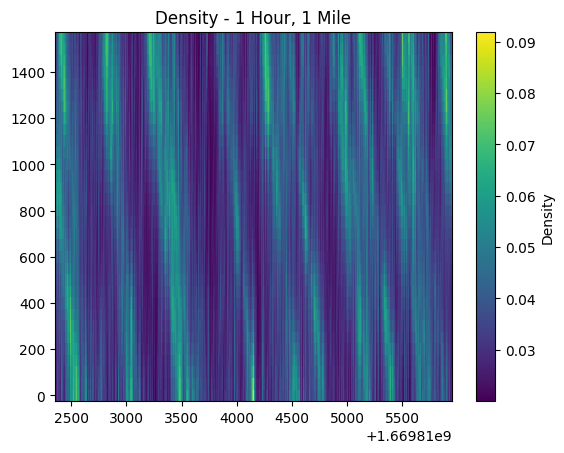

In [4]:
queries = i24macro.computeEdieBoxQueries()
timestamp_min_display = numpy.array(queries["timestamp_min"]).reshape((36000, 32))
s_min_display = numpy.array(queries["s_min"]).reshape((36000, 32))
density_result_asm_output_display = i24macro_data[-1]["density"].reshape(36000, 32)
print(density_result_asm_output_display.shape)
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_asm_output_display, cmap='viridis', shading='auto')
plt.title('Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

In [4]:
i24macro_data[-1]['velocity'].shape

(1800, 16)

In [21]:
start_timestamp = 1669812350+35.0
start_s = 150

def findClosestVehicle(timestamp, s, margin_s=50.0, margin_time=10.0, trajectory_min_length=4, greater_than_s=False):
    vehicles = i24data.queryEdieBoxBatch([timestamp], [timestamp + margin_time], [s - margin_s], [s + margin_s])[0]
    vehicles_all_lanes = pandas.concat([vehicles[lane].assign(lane=lane) for lane in vehicles])
    vehicles_lane_additional = vehicles_all_lanes.copy(deep=True)
    if greater_than_s:
        vehicles_lane_additional = vehicles_lane_additional[vehicles_lane_additional["s"] >= s]
    vehicles_lane_additional["s_distance"] = (vehicles_lane_additional["s"] - s).abs()
    vehicles_lane_additional["time_distance"] = (vehicles_lane_additional["time"] - timestamp).abs()
    vehicles_lane_additional["merged_distance"] = (vehicles_lane_additional["s_distance"] ** 2) + (vehicles_lane_additional["time_distance"] ** 2)
    vehicles_lane_additional_sorted = vehicles_lane_additional.sort_values(by=["merged_distance"], ascending=[True])
    i = 0
    while (i <= len(vehicles_lane_additional_sorted)):
        current_vehicle = vehicles_lane_additional_sorted.iloc[i]
        current_vehicle_trajectory = vehicles_lane_additional_sorted[(vehicles_lane_additional_sorted["id"] == current_vehicle["id"]) & (vehicles_lane_additional_sorted["time"] >= current_vehicle["time"]) & (vehicles_lane_additional_sorted["lane"] == current_vehicle["lane"])]
        if (len(current_vehicle_trajectory) >= trajectory_min_length):
            return current_vehicle
        i = i + 1
    return None

def createMicroscopicBox(s, timestamp, margin_s, margin_time=0.5):
    vehicles = i24data.queryEdieBoxBatch([timestamp - margin_time], [timestamp + margin_time], [s - margin_s], [s + margin_s])[0]
    vehicles_all_lanes = pandas.concat([vehicles[lane].assign(lane=lane) for lane in vehicles])
    vehicles_unique_ids = vehicles_all_lanes["id"].unique().tolist()
    final_data = {}
    feet_to_meters = 0.3048
    for id in vehicles_unique_ids:
        vehicle_id_data = vehicles_all_lanes[vehicles_all_lanes["id"] == id]
        vehicle_id_data_copied = vehicle_id_data.copy(deep=True)
        vehicle_id_data_copied["time_distance"] = (vehicle_id_data_copied["time"] - timestamp).abs()
        vehicle_id_data_copied_sorted = vehicle_id_data_copied.sort_values(by=["time_distance"], ascending=[True])
        vehicle_selected = vehicle_id_data_copied_sorted.iloc[0].to_dict()
        vehicle_selected["x"] = vehicle_selected["x"] * feet_to_meters
        vehicle_selected["y"] = vehicle_selected["y"] * feet_to_meters
        vehicle_selected["length"] = vehicle_selected["length"] * feet_to_meters
        vehicle_selected["width"] = vehicle_selected["width"] * feet_to_meters
        vehicle_selected["height"] = vehicle_selected["height"] * feet_to_meters
        final_data[id] = vehicle_selected
    return final_data

'''
def cleanMicroscopicBox(box):
    result = {}
    for id in box:
        entry = box[id]
        colliding = False
        for id2 in box:
            entry2 = box[id2]
            if (id2 == id):
                continue
            colliding = colliding or (entry2[])
'''


def plot_vehicles_2d(
    vehicles: dict,
    ax=None,
    hero_id=None,
    color_by_class: bool = True,
    show_ids: bool = False,
    center_on_xy: bool = False,
    invert_y: bool = False,
    equal_aspect: bool = True,
    margin_s: float = 10.0
):
    """
    Plot a top-down 2D view of vehicles.

    Coordinate convention:
      - x: longitudinal (forward/backward)
      - y: lateral (left-to-right)

    Expected vehicle format:
    vehicles[id] = {
        "time": time,
        "x": x,
        "y": y,
        "length": length,
        "width": width,
        "height": height,
        "class": class,
        "id": id,
        "s": s,
        "t": t
    }

    Assumptions:
      - Vehicles are axis-aligned in the x-y plane.
      - "x", "y" are the vehicle center coordinates by default.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(24, 12))
    else:
        fig = ax.figure

    class_colors = {
        "hero": "tab:red",
        "car": "tab:blue",
        "truck": "tab:orange",
        "bus": "tab:green",
        "motorcycle": "tab:yellow",
        "bicycle": "tab:purple",
        "pedestrian": "tab:brown",
    }

    all_x_min, all_x_max = [], []
    all_y_min, all_y_max = [], []

    for vid, veh in vehicles.items():
        id = veh["id"]
        x = veh["s"]
        y = veh["t"]
        length = veh["length"]
        width = veh["width"]
        cls = veh.get("class", "unknown")
        if (hero_id is not None) and (id == hero_id):
            cls = "hero"

        # If x,y are vehicle centers, convert to lower-center for Rectangle
        if center_on_xy:
            x0 = x - length / 2.0
            y0 = y - width / 2.0
        else:
            x0 = x
            y0 = y - width / 2.0

        color = class_colors.get(cls, "gray") if color_by_class else "tab:blue"

        rect = Rectangle(
            (x0, y0),
            length,
            width,
            facecolor=color,
            edgecolor="black",
            linewidth=1.0,
            alpha=0.8,
        )
        ax.add_patch(rect)

        # Mark vehicle center
        ax.plot(x, y, "k.", markersize=4)

        if show_ids:
            ax.text(
                x,
                y,
                str(veh.get("id", vid)),
                fontsize=8,
                ha="center",
                va="center",
                color="white",
                weight="bold",
            )

        all_x_min.append(x0)
        all_x_max.append(x0 + length)
        all_y_min.append(y0)
        all_y_max.append(y0 + width)

    if all_x_min:
        pad_x = margin_s
        pad_y = max(1.0, 0.05 * (max(all_y_max) - min(all_y_min)))

        ax.set_xlim(min(all_x_min) - pad_x, max(all_x_max) + pad_x)
        ax.set_ylim(min(all_y_min) - pad_y, max(all_y_max) + pad_y)

    ax.set_xlabel("Longitudinal position x")
    ax.set_ylabel("Lateral position y")
    ax.set_title("2D Top-Down Vehicle View")
    ax.grid(True, linestyle="--", alpha=0.4)

    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")

    if invert_y:
        ax.invert_yaxis()

    return fig, ax

def generateVehicleSlidingWindow(start_timestamp, start_s, end_timestamp, time_step=0.1, margin_s=100.0):
    current_vehicle = findClosestVehicle(start_timestamp, start_s, trajectory_min_length=8)
    current_vehicle_trajectory = i24data.getVehicleTrajectory(int(current_vehicle["lane"]), current_vehicle["id"], start_time=float(current_vehicle["time"]))
    result = []
    timesteps = numpy.arange(start_timestamp, end_timestamp+time_step, step=time_step)
    for step in timesteps:
        print(step - start_timestamp, current_vehicle["s"])
        box = createMicroscopicBox(current_vehicle["s"], current_vehicle["time"], margin_s=margin_s)
        entry = {
            "current_vehicle": current_vehicle,
            "box": box,
            "timestamp": step,
            "s": current_vehicle["s"],
            "margin_s": margin_s
        }
        trajectory_next = current_vehicle_trajectory[current_vehicle_trajectory["time"] > current_vehicle["time"]].sort_values(by=["time"], ascending=[True]).iloc[0]
        current_vehicle = findClosestVehicle(trajectory_next["time"], trajectory_next["s"], trajectory_min_length=8)
        current_vehicle_trajectory = i24data.getVehicleTrajectory(int(current_vehicle["lane"]), current_vehicle["id"], start_time=float(current_vehicle["time"]))
        #print(current_vehicle_trajectory)
        result.append(entry)
    return result

#current_vehicle = findClosestVehicle(start_timestamp, start_s, trajectory_min_length=8)
#box = createMicroscopicBox(current_vehicle["s"], current_vehicle["time"], 100)
#box = cleanMicroscopicBox(box)
#plot_vehicles_2d(box, invert_y=False)
#windows = generateVehicleSlidingWindow(start_timestamp, start_s, start_timestamp+90)

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '2D Top-Down Vehicle View'}, xlabel='Longitudinal position x', ylabel='Lateral position y'>)

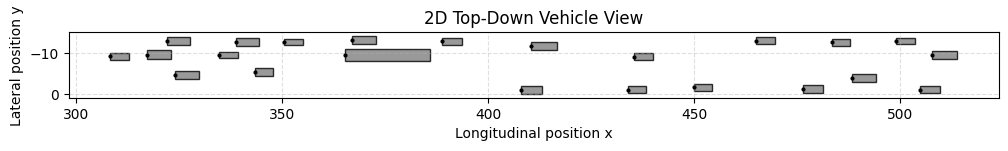

In [6]:
plot_vehicles_2d(windows[580]["box"], invert_y=True)

In [7]:
def vehicle_sequence_slider_fixed_bounds(windows):
    output = widgets.Output()
    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=len(windows) - 1,
        step=10,
        description="Frame",
        continuous_update=False,
    )

    def update(frame_idx):
        with output:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(12, 6))
            margin = 10.0
            y_max = 5.0
            y_min = -20.0
            plot_vehicles_2d(
                windows[frame_idx]["box"],
                ax=ax,
                hero_id=windows[frame_idx]["current_vehicle"]["id"],
                margin_s=margin,
            )
            # Add margin rectangles!
            width = margin
            height = y_max - y_min
            x0 = windows[frame_idx]["s"] - windows[frame_idx]["margin_s"] - margin
            y0 = y_min
            rect = Rectangle(
                (x0, y0),
                width,
                height,
                facecolor="yellow",
                edgecolor="black",
                linewidth=1.0,
                alpha=0.8,
            )
            ax.add_patch(rect)

            x0 = windows[frame_idx]["s"] + windows[frame_idx]["margin_s"]
            y0 = y_min
            rect = Rectangle(
                (x0, y0),
                width,
                height,
                facecolor="yellow",
                edgecolor="black",
                linewidth=1.0,
                alpha=0.8,
            )
            ax.add_patch(rect)
            ax.set_xlim(windows[frame_idx]["s"] - windows[frame_idx]["margin_s"] - margin, windows[frame_idx]["s"] + windows[frame_idx]["margin_s"] + margin)
            ax.set_ylim(y_min, y_max)
            ax.set_title(f"2D Top-Down Vehicle View — Frame {frame_idx}")
            plt.show()

    widgets.interactive_output(update, {"frame_idx": slider})
    display(slider, output)
    update(0)

vehicle_sequence_slider_fixed_bounds(windows)

IntSlider(value=0, continuous_update=False, description='Frame', max=900, step=10)

Output()

# Lets now put the macroscopic data side by side with it!

In [ ]:
start_timestamp = 1669812350+400.0
start_s = 175

def generateMacroData(i24data, i24macro, macro_data, s, timestep, lane, behind=False):
    s_index_float = (s - i24data.s_min) / i24macro.longitudinal_cell_size
    time_index_float = (timestep - i24data.timestamp_min) / i24macro.time_delta
    time_index_clipped = math.floor(time_index_float)
    s_index_clipped = math.floor(s_index_float) if behind else math.ceil(s_index_float)
    result = {
        "flow": float(macro_data[lane]["flow"][time_index_clipped][s_index_clipped]),
        "density": float(macro_data[lane]["density"][time_index_clipped][s_index_clipped]),
        "velocity": float(macro_data[lane]["velocity"][time_index_clipped][s_index_clipped])
    }
    return result
    

def generateVehicleSlidingWindow(start_timestamp, start_s, end_timestamp, time_step=0.1, margin_s=150.0):
    current_vehicle = findClosestVehicle(start_timestamp, start_s, trajectory_min_length=4)
    current_vehicle_trajectory = i24data.getVehicleTrajectory(int(current_vehicle["lane"]), current_vehicle["id"], start_time=float(current_vehicle["time"]))
    result = []
    timesteps = numpy.arange(start_timestamp, end_timestamp+time_step, step=time_step)
    for step in timesteps:
        print(step - start_timestamp, current_vehicle["s"])
        box = createMicroscopicBox(current_vehicle["s"], current_vehicle["time"], margin_s=margin_s)
        entry = {
            "current_vehicle": current_vehicle,
            "box": box,
            "timestamp": step,
            "s": current_vehicle["s"],
            "s_velocity": float(current_vehicle_trajectory.iloc[1]["s"] - current_vehicle_trajectory.iloc[0]["s"]) / float(current_vehicle_trajectory.iloc[1]["time"] - current_vehicle_trajectory.iloc[0]["time"] + 1e-8),
            "margin_s": margin_s,
            "macro": {
                "left": {
                    "-1": generateMacroData(i24data, i24macro, i24macro_data, current_vehicle["s"] - margin_s, step, -1, behind=True),
                    "-2": generateMacroData(i24data, i24macro, i24macro_data, current_vehicle["s"] - margin_s, step, -2, behind=True),
                    "-3": generateMacroData(i24data, i24macro, i24macro_data, current_vehicle["s"] - margin_s, step, -3, behind=True),
                    "-4": generateMacroData(i24data, i24macro, i24macro_data, current_vehicle["s"] - margin_s, step, -4, behind=True),
                },
                "right": {
                    "-1": generateMacroData(i24data, i24macro, i24macro_data, current_vehicle["s"] + margin_s, step, -1, behind=False),
                    "-2": generateMacroData(i24data, i24macro, i24macro_data, current_vehicle["s"] + margin_s, step, -2, behind=False),
                    "-3": generateMacroData(i24data, i24macro, i24macro_data, current_vehicle["s"] + margin_s, step, -3, behind=False),
                    "-4": generateMacroData(i24data, i24macro, i24macro_data, current_vehicle["s"] + margin_s, step, -4, behind=False),
                },
            }
        }
        trajectory_next = current_vehicle_trajectory[current_vehicle_trajectory["time"] > current_vehicle["time"]].iloc[0]
        current_vehicle = findClosestVehicle(trajectory_next["time"], trajectory_next["s"], trajectory_min_length=8, margin_s=100.0, greater_than_s=True)
        current_vehicle_trajectory = i24data.getVehicleTrajectory(int(current_vehicle["lane"]), current_vehicle["id"])
        current_vehicle_trajectory = current_vehicle_trajectory[current_vehicle_trajectory["time"] >= current_vehicle["time"]].sort_values(by=["time"], ascending=[True])
        result.append(entry)
    return result

#current_vehicle = findClosestVehicle(start_timestamp, start_s, trajectory_min_length=8)
#box = createMicroscopicBox(current_vehicle["s"], current_vehicle["time"], 100)
#box = cleanMicroscopicBox(box)
#plot_vehicles_2d(box, invert_y=False)
windows_with_macro = generateVehicleSlidingWindow(start_timestamp, start_s, start_timestamp+90)

0.0 175.12679369204304
0.09999990463256836 175.57428029964694
0.19999980926513672 176.02400871701315
0.2999997138977051 176.47600061737447
0.39999961853027344 176.930279995616
0.4999995231628418 177.38687294696055
0.5999994277954102 177.84580746454492
0.6999993324279785 178.30711320233652
0.7999992370605469 178.77082125939913
0.8999991416931152 179.23696393339847
0.9999990463256836 179.70557449521675
1.099998950958252 180.1766869829612
1.1999988555908203 180.65033596601276
1.2999987602233887 181.12655632623873
1.399998664855957 181.6053830089253
1.4999985694885254 182.08685078695206
1.5999984741210938 182.57099403595538
1.699998378753662 183.05784650584434
1.7999982833862305 183.5474410982739
1.8999981880187988 184.0398096372346
1.9999980926513672 184.5349826399278
2.0999979972839355 185.0329890845764
2.199997901916504 185.53385622116306
2.2999978065490723 186.0376093740606
2.3999977111816406 186.54427178361055
2.499997615814209 187.05386443271013
2.5999975204467773 187.56640585127255


In [39]:
windows_with_macro[300]["s_velocity"]

2.379557852313494

In [24]:
def vehicle_sequence_slider_fixed_bounds_macro(windows):
    output = widgets.Output()
    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=len(windows) - 1,
        step=1,
        description="Frame",
        continuous_update=False,
    )
    lane_y_position = {
        "-1": -3.6576,
        "-2": -3.6576*2,
        "-3": -3.6576*3,
        "-4": -3.6576*4,
    }
    lane_y_size = 3.6576


    def update(frame_idx):
        with output:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(12, 6))
            margin = 10.0
            y_max = 5.0
            y_min = -20.0
            plot_vehicles_2d(
                windows[frame_idx]["box"],
                ax=ax,
                hero_id=windows[frame_idx]["current_vehicle"]["id"],
                margin_s=margin,
            )
            # Add margin rectangles!
            for lane in lane_y_position:
                density_left = windows[frame_idx]["macro"]["left"][lane]["density"]
                density_right = windows[frame_idx]["macro"]["right"][lane]["density"]
                velocity_left = windows[frame_idx]["macro"]["left"][lane]["velocity"] - windows[frame_idx]["s_velocity"]
                velocity_right = windows[frame_idx]["macro"]["right"][lane]["velocity"] - windows[frame_idx]["s_velocity"]
                flow_left = density_left * velocity_left
                flow_right = density_right * velocity_right
                width = margin
                height = lane_y_size
                x0 = windows[frame_idx]["s"] - windows[frame_idx]["margin_s"] - margin
                y0 = lane_y_position[lane]
                rect = Rectangle(
                    (x0, y0),
                    width,
                    height,
                    facecolor="yellow",
                    edgecolor="black",
                    linewidth=1.0,
                    alpha=0.8,
                )
                ax.add_patch(rect)

                cx = x0 + (width / 2)
                cy = y0 + (height / 2)

                ax.text(cx, cy, f"{flow_left:2.2f}",
                        horizontalalignment='center',
                        verticalalignment='center',
                        fontsize=12,
                        color='black')

                x0 = windows[frame_idx]["s"] + windows[frame_idx]["margin_s"]
                rect = Rectangle(
                    (x0, y0),
                    width,
                    height,
                    facecolor="yellow",
                    edgecolor="black",
                    linewidth=1.0,
                    alpha=0.8,
                )
                ax.add_patch(rect)

                cx = x0 + (width / 2)
                cy = y0 + (height / 2)

                ax.text(cx, cy, f"{flow_right:2.2f}",
                        horizontalalignment='center',
                        verticalalignment='center',
                        fontsize=12,
                        color='black')
            ax.set_xlim(windows[frame_idx]["s"] - windows[frame_idx]["margin_s"] - margin, windows[frame_idx]["s"] + windows[frame_idx]["margin_s"] + margin)
            ax.set_ylim(y_min, y_max)
            ax.set_title(f'2D Top-Down Vehicle View — Frame {frame_idx}, Ego Velocity {windows[frame_idx]["s_velocity"]}, Left Velocity {windows[frame_idx]["macro"]["left"][lane]["velocity"]}, Right Velocity {windows[frame_idx]["macro"]["right"][lane]["velocity"]}')
            plt.show()

    widgets.interactive_output(update, {"frame_idx": slider})
    display(slider, output)
    update(0)

vehicle_sequence_slider_fixed_bounds_macro(windows_with_macro)

IntSlider(value=0, continuous_update=False, description='Frame', max=900)

Output()